In [1]:
import pandas as pd

data = {
    "Ligand": [
        "Aspirin",
        "Caffeine",
        "Curcumin",
        "Ibuprofen",
        "Naproxen",
        "Nicotine",
        "Paracetamol",
        "Quercetin",
        "Resveratrol",
        "Metformin"
    ],

    "DockingScore": [
        -5.5,
        -5.2,
        -6.5,
        -6.5,
        -6.1,
        -5.5,
        -4.8,
        -8.5,
        -6.1,
        -4.8
    ],

    "Label": [
        "Weak",
        "Weak",
        "Strong",
        "Strong",
        "Strong",
        "Weak",
        "Weak",
        "Strong",
        "Strong",
        "Weak"
    ]
}

df = pd.DataFrame(data)

print(df)

        Ligand  DockingScore   Label
0      Aspirin          -5.5    Weak
1     Caffeine          -5.2    Weak
2     Curcumin          -6.5  Strong
3    Ibuprofen          -6.5  Strong
4     Naproxen          -6.1  Strong
5     Nicotine          -5.5    Weak
6  Paracetamol          -4.8    Weak
7    Quercetin          -8.5  Strong
8  Resveratrol          -6.1  Strong
9    Metformin          -4.8    Weak


In [2]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, confusion_matrix

# Convert labels into numbers
encoder = LabelEncoder()
df["LabelEncoded"] = encoder.fit_transform(df["Label"])

# Features and target
X = df[["DockingScore"]]
y = df["LabelEncoded"]

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# Create model
model = RandomForestClassifier()

# Train model
model.fit(X_train, y_train)

# Predict
y_pred = model.predict(X_test)

# Accuracy
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
print(cm)

Accuracy: 1.0
[[1 0]
 [0 2]]


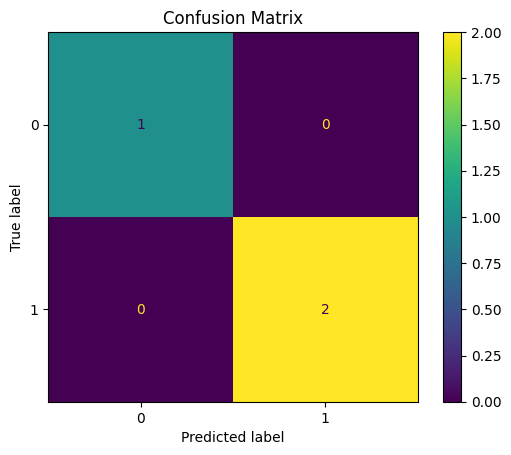

In [3]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

# Display confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm)

disp.plot()

plt.title("Confusion Matrix")

plt.show()